In [6]:
#.upper() is a built-in Python command that converts text into ALL CAPITAL LETTERS.

In [11]:
# ==========================================
# CELL 1: TRAINING BLOCK (50 Epochs)
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# --- CONFIGURATION ---
DATA_DIR = "dataset_spectrograms"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 50  # Increased to 50 for maximum accuracy

# Check data
if not os.path.exists(DATA_DIR):
    print(f"❌ ERROR: Folder '{DATA_DIR}' not found. Run Step 1 first!")
    raise SystemExit

# --- LOAD DATA ---
print("--- 1. Loading Images... ---")
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    #flow_from_directory: This is a magic function. You just point it at a folder, and it automatically looks inside, 
    #finds the subfolders (healthy vs seizure), and figures out the labels. 
    #You don't have to write code to say "healthy is 0". It does it for you.
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    subset='validation'
)

# --- BUILD MODEL ---
print("\n--- 2. Building the Brain... ---")
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    #Conv2D(32): This creates 32 small scanners (filters). 
#They slide over the image looking for very simple things: vertical lines, horizontal lines, and corners.
# input_shape=(128, 128, 1): Tells the AI, "Expect a picture that is 128x128 pixels and Black & White (1 channel)."
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    
 # FROM AFTER LAYER 3
# Up until now, the Conv2D and MaxPooling layers were just 
# Eyes—they were looking at the image and finding shapes (lines, spikes, patterns). 
# Now, we need a Brain to take those shapes and actually decide: "Is this a seizure?"
    
    
    
# model.add(Dense(128, activation='relu'))
# What it is: This is a Fully Connected Layer.
# How it works: You are creating 128 neurons. Every single one of these neurons looks at every single number from the flattened list above.
# the Job: This is where the "Thinking" happens. The neurons look at the relationships between the features.
# Example: "I see a 'spike' feature AND a 'high energy' feature together? That usually means a seizure."
    
    
# model.add(Dropout(0.5))
# The "Anti-Cheating" 
# Mechanism: During training, this layer randomly turns off 50% of the neurons (sets them to zero) for every single step.
    
    
# model.add(Dense(1, activation='sigmoid'))
# The Final Verdict: This is the output layer.
# Dense(1): We only need 1 single neuron because we only have one question: "Is this a seizure?"
# activation='sigmoid': This is a mathematical function that squashes the final number into a probability between 0 and 1.
# 0.0 = Definitely Healthy
# 1.0 = Definitely Seizure
# 0.5 = "I have no idea."
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer="adam", loss='binary_crossentropy', metrics=['accuracy'])

# --- TRAIN ---
print(f"\n--- 3. Starting Training for {EPOCHS} Epochs... ---")
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS)

# --- SAVE (Backup) ---
model.save("seizure_detection_model.h5")
print("\n✅ CELL 1 COMPLETE: Model is trained and alive in memory.")
print("👉 ACTION: Now run Cell 2 immediately.")

--- 1. Loading Images... ---
Found 916 images belonging to 2 classes.
Found 228 images belonging to 2 classes.

--- 2. Building the Brain... ---

--- 3. Starting Training for 50 Epochs... ---
Epoch 1/50


2026-01-02 11:52:59.063289: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


29/29 [==============================] - ETA: 0s - loss: 0.5192 - accuracy: 0.8428

2026-01-02 11:53:02.312595: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


29/29 [==============================] - 4s 80ms/step - loss: 0.5192 - accuracy: 0.8428 - val_loss: 0.4161 - val_accuracy: 0.8553
Epoch 2/50
29/29 [==============================] - 2s 69ms/step - loss: 0.4320 - accuracy: 0.8559 - val_loss: 0.4127 - val_accuracy: 0.8553
Epoch 3/50
29/29 [==============================] - 2s 65ms/step - loss: 0.4300 - accuracy: 0.8559 - val_loss: 0.4129 - val_accuracy: 0.8553
Epoch 4/50
29/29 [==============================] - 2s 71ms/step - loss: 0.4160 - accuracy: 0.8559 - val_loss: 0.4053 - val_accuracy: 0.8553
Epoch 5/50
29/29 [==============================] - 2s 78ms/step - loss: 0.4243 - accuracy: 0.8559 - val_loss: 0.4015 - val_accuracy: 0.8553
Epoch 6/50
29/29 [==============================] - 2s 67ms/step - loss: 0.4083 - accuracy: 0.8559 - val_loss: 0.4273 - val_accuracy: 0.8553
Epoch 7/50
29/29 [==============================] - 2s 79ms/step - loss: 0.3859 - accuracy: 0.8559 - val_loss: 0.3322 - val_accuracy: 0.8553
Epoch 8/50
29/29 [======

✅ AI Brain found in memory! Proceeding...
🔎 Testing Image: chb01_16_261.png


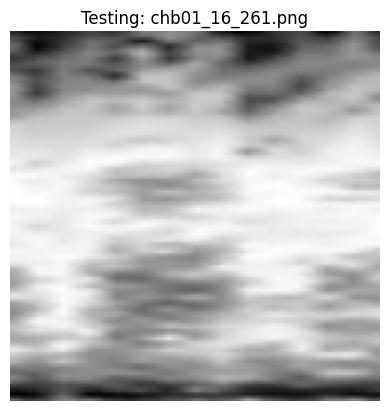

1/1 [==============================] - 0s 28ms/step
--------------------------------------
🤖 AI Confidence Score: 0.5855
🤖 AI Says:   SEIZURE
✅ Real Fact: SEIZURE
--------------------------------------
🎉 SUCCESS: The AI was correct!


In [16]:
# ==========================================
# CELL 2: BLIND TEST BLOCK
# ==========================================
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image # Safe image loader

# 1. CHECK IF AI EXISTS
try:
    model
    print(f"✅ AI Brain found in memory! Proceeding...")
except NameError:
    print("❌ ERROR: The AI is missing. You MUST run Cell 1 first.")
    print("Do not restart the kernel between Cell 1 and Cell 2.")
    raise SystemExit 

# 2. PICK RANDOM IMAGE
DATA_DIR = "dataset_spectrograms"
categories = ["seizure", "healthy"]
chosen_category = random.choice(categories) 

folder_path = os.path.join(DATA_DIR, chosen_category)
files = os.listdir(folder_path)
img_filename = random.choice(files)
image_path = os.path.join(folder_path, img_filename)

print(f"🔎 Testing Image: {img_filename}")

# 3. SHOW IMAGE
img = Image.open(image_path).convert('L')
img = img.resize((128, 128))

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title(f"Testing: {img_filename}")
plt.show()

# 4. PREDICT
img_array = np.array(img)

# 1. ADD BATCH DIMENSION
# The AI was trained to eat images in "stacks" (batches) of 32 at a time.
# Even if you only have ONE image, you must trick the AI into thinking it is a "stack of one."
# BEFORE: Shape is (128, 128) -> Just a flat grid of pixels.
img_array = np.expand_dims(img_array, axis=0) # Batch
# AFTER:  Shape is (1, 128, 128) -> A list containing one image.


# 2. ADD CHANNEL DIMENSION
# Grayscale images are 2D (Height x Width), but the AI expects 3D volume (Height x Width x ColorDepth).
# Even though it's black and white, we must explicitly tell the AI "Depth = 1".
# BEFORE: Shape is (1, 128, 128)
img_array = np.expand_dims(img_array, axis=-1) # Channel
# AFTER:  Shape is (1, 128, 128, 1) -> (1 Image, 128 High, 128 Wide, 1 Color Channel)


# 3. NORMALIZE (THE MATH STEP)
# Raw pixels are integers from 0 (black) to 255 (white).
# However, during training (Step 2), we used "rescale=1./255", so the AI learned on small decimals (0.0 to 1.0).
# If you feed it a raw "255", it will think that is a GIANT explosion of energy and give wrong results.
# We divide by 255.0 to shrink the numbers down to match the training data.
# BEFORE: Values are [0, 255]
img_array = img_array / 255.0  # Normalize
# AFTER:  Values are [0.0, 1.0]


prediction = model.predict(img_array)
score = prediction[0][0]

# 5. RESULTS
print(f"--------------------------------------")
print(f"🤖 AI Confidence Score: {score:.4f}")

if score > 0.5:
    ai_result = "SEIZURE"
else:
    ai_result = "HEALTHY"

print(f"🤖 AI Says:   {ai_result}")
print(f"✅ Real Fact: {chosen_category.upper()}")
print(f"--------------------------------------")

if ai_result == chosen_category.upper():
    print("🎉 SUCCESS: The AI was correct!")
else:
    print("⚠️ FAILURE: The AI got it wrong.")